In [2]:
!git clone https://github.com/sea3551/palm-sEMG-doorknob-filtered.git data

fatal: destination path 'data' already exists and is not an empty directory.


In [3]:
!pip install -q pymupdf

import numpy, scipy, sklearn
print('OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 36.8 MB/s eta 0:00:00
OK


In [4]:
import os
import glob
import numpy as np
from collections import Counter

if os.path.exists('/content/semg-auth'):
    os.chdir('/content/semg-auth')

# 2. 파일 목록 수집
files = sorted(glob.glob('data/**/*.csv', recursive=True))
print('파일 개수:', len(files))
print('예시 경로:', files[0])

# 3. 첫 번째 파일 로드 및 확인
x = np.loadtxt(files[0], delimiter=',', skiprows=1)
print('배열 모양:', x.shape)
print('값 범위:', x.min(0), '~', x.max(1))

# 4. 피험자별 파일 수 세기
subs = [os.path.basename(os.path.dirname(f)) for f in files]
print('피험자별 개수:', Counter(subs))

파일 개수: 250
예시 경로: data/data/A/a (1).csv
배열 모양: (3000, 2)
값 범위: [-3.53656  -0.282713] ~ [-0.0105196  -0.0121542  -0.00213719 ...  0.0128519   0.030492
  0.0414297 ]
피험자별 개수: Counter({'A': 50, 'B': 50, 'C': 50, 'D': 50, 'E': 50})


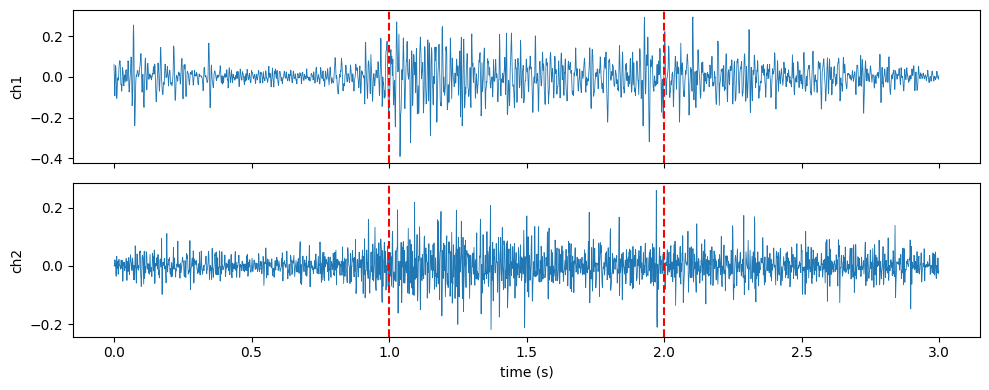

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# skiprows=1 추가: 헤더('Comp Ch 3' 등 문자열) 행 건너뛰기
x = np.loadtxt(files[100], delimiter=',', skiprows=1)

if x.shape[0] < x.shape[1]:
    x = x.T     # (시간, 채널) 로 통일

t = np.arange(len(x)) / 1000.0          # 1000 Hz -> 초 단위

fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for ch in range(2):
    ax[ch].plot(t, x[:, ch], lw=0.6)
    ax[ch].set_ylabel(f'ch{ch+1}')

for a in ax:
    a.axvline(1.0, color='r', ls='--')
    a.axvline(2.0, color='r', ls='--')

ax[1].set_xlabel('time (s)')
plt.tight_layout()

# 이미지 저장 및 화면 출력
plt.savefig('signal_example.png', dpi=120)
plt.show()

2주차 시작 2.1 필터확

In [6]:
from scipy.signal import butter, iirnotch, filtfilt
FS = 1000
def preprocess(x, fs=FS):
  # 1) 60 Hz 전원선 잡음 제거
  bn, an = iirnotch(60, 30, fs)
  x = filtfilt(bn, an, x, axis=0)
  # 2) 20~499 Hz 대역만 통과 (4차)
  b, a = butter(4, [20/(fs/2), 499/(fs/2)], btype='band')
  return filtfilt(b, a, x, axis=0)
xf = preprocess(x)
print('전:', x.std(), ' 후:', xf.std())

전: 0.05662068386596064  후: 0.05580814695521503


2.2 필터확인

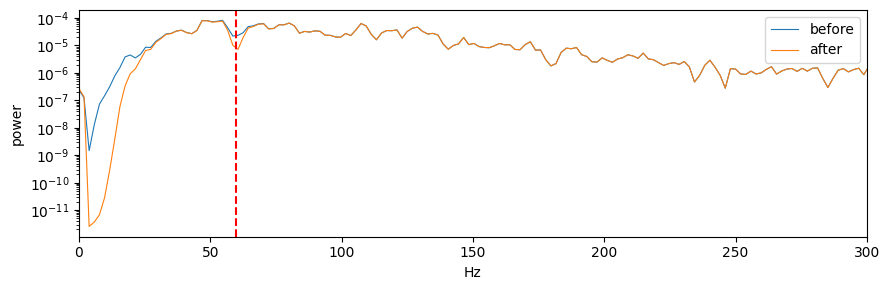

In [7]:
import matplotlib.pyplot as plt
from scipy.signal import welch
f0, P0 = welch(x[:, 0], fs=FS, nperseg=512)
f1, P1 = welch(xf[:, 0], fs=FS, nperseg=512)
plt.figure(figsize=(9, 3))
plt.semilogy(f0, P0, label='before', lw=0.8)
plt.semilogy(f1, P1, label='after', lw=0.8)
plt.axvline(60, color='r', ls='--')
plt.xlim(0, 300); plt.legend()
plt.xlabel('Hz'); plt.ylabel('power')
plt.tight_layout(); plt.savefig('filter_check.png', dpi=120)

2.3슬라이딩 윈도우로 자르기

In [8]:
WIN, HOP = 300, 150 # 샘플 단위 (1000Hz -> 300ms, 150ms)
def make_windows(x, win=WIN, hop=HOP):
  """x: (시간, 채널) -> (윈도우수, win, 채널)"""
  n = (len(x) - win) // hop + 1
  return np.stack([x[i*hop : i*hop+win] for i in range(n)])
w = make_windows(xf)
print('윈도우 배열 모양:', w.shape) # (19, 300, 2)


윈도우 배열 모양: (19, 300, 2)


2.4 min-max 정규화

In [9]:
def minmax(w, eps=1e-8):
  """w: (윈도우수, 시간, 채널)"""
  mn = w.min(axis=(1, 2), keepdims=True)
  mx = w.max(axis=(1, 2), keepdims=True)
  return (w - mn) / (mx - mn + eps)
wn = minmax(w)
print('값 범위:', wn.min(), '~', wn.max())

값 범위: 0.0 ~ 0.9999999841593685


2.5 CWT 변환

In [10]:
import numpy as np
import pywt

SCALES = np.arange(1, 33)

def to_cwt(one_window, wavelet='morl'):
    """(300, 2) -> (3, 32, 300)"""

    maps = []

    for ch in range(one_window.shape[1]):
        coef, _ = pywt.cwt(
            one_window[:, ch],
            SCALES,
            wavelet
        )
        maps.append(np.abs(coef))

    # 두 채널 평균을 3번째 채널로 추가
    maps.append((maps[0] + maps[1]) / 2)

    return np.stack(maps).astype(np.float32)


t = to_cwt(wn[0])

print('입력 텐서 모양:', t.shape)

입력 텐서 모양: (3, 32, 300)


2.6(a) 교재에 없음 라벨만들기

In [11]:
from pathlib import Path
import numpy as np
from sklearn.model_selection import train_test_split

# 클래스 이름 추출
class_names = sorted(set(Path(f).parent.name for f in files))

class_to_idx = {
    name: idx
    for idx, name in enumerate(class_names)
}

def label_of(f):
    return class_to_idx[Path(f).parent.name]

labels = np.array([label_of(f) for f in files])

print("클래스:", class_names)
print("클래스 번호:", class_to_idx)
print("전체 파일 수:", len(files))
print("전체 라벨 수:", len(labels))


# CSV 읽기 함수 추가
def load(f):
    x = np.loadtxt(
        f,
        delimiter=',',
        skiprows=1
    )

    if x.shape[0] < x.shape[1]:
        x = x.T

    return x


# 시행 단위로 먼저 분할
tr_files, te_files = train_test_split(
    files,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

def build(flist):
    X, y = [], []

    for f in flist:
        sig = preprocess(load(f))

        for w in minmax(make_windows(sig)):
            X.append(to_cwt(w))
            y.append(label_of(f))

    return np.stack(X), np.array(y)

Xtr, ytr = build(tr_files)
Xte, yte = build(te_files)

print("Xtr:", Xtr.shape, "ytr:", ytr.shape)
print("Xte:", Xte.shape, "yte:", yte.shape)

클래스: ['A', 'B', 'C', 'D', 'E']
클래스 번호: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
전체 파일 수: 250
전체 라벨 수: 250
Xtr: (3800, 3, 32, 300) ytr: (3800,)
Xte: (950, 3, 32, 300) yte: (950,)


In [12]:
import pandas as pd

train_count = np.bincount(ytr, minlength=5)
test_count = np.bincount(yte, minlength=5)

summary = pd.DataFrame({
    'Class': ['A', 'B', 'C', 'D', 'E'],
    'Train Samples': train_count,
    'Test Samples': test_count
})

display(summary)

print("전체 Train 샘플 수:", len(ytr))
print("전체 Test 샘플 수 :", len(yte))

,Class,Train Samples,Test Samples
0,A,760,190
1,B,760,190
2,C,760,190
3,D,760,190
4,E,760,190


전체 Train 샘플 수: 3800
전체 Test 샘플 수 : 950


2.7 데이터셋 만들기

In [13]:
from sklearn.model_selection import train_test_split

# 1) 시행 단위로 먼저 분할
tr_files, te_files = train_test_split(
    files,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# 2) 각 집합 안에서만 윈도우 생성
def build(flist):
    X, y = [], []

    for f in flist:
        sig = preprocess(load(f))

        for w in minmax(make_windows(sig)):
            X.append(to_cwt(w))
            y.append(label_of(f))

    return np.stack(X), np.array(y)

Xtr, ytr = build(tr_files)
Xte, yte = build(te_files)

print("Xtr:", Xtr.shape, "ytr:", ytr.shape)
print("Xte:", Xte.shape, "yte:", yte.shape)

Xtr: (3800, 3, 32, 300) ytr: (3800,)
Xte: (950, 3, 32, 300) yte: (950,)


2.7 학습

In [14]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# NumPy 배열 -> PyTorch Tensor
Xtr_tensor = torch.tensor(Xtr, dtype=torch.float32)
ytr_tensor = torch.tensor(ytr, dtype=torch.long)

# Dataset 생성
train_dataset = TensorDataset(
    Xtr_tensor,
    ytr_tensor
)

# DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

print("학습 데이터 수:", len(train_dataset))
print("배치 수:", len(train_loader))

학습 데이터 수: 3800
배치 수: 238


In [15]:
import torch
import torch.nn as nn
from torchvision.models import densenet161

# GPU 사용 가능하면 GPU
dev = 'cuda' if torch.cuda.is_available() else 'cpu'

print("사용 장치:", dev)

# DenseNet161
model = densenet161(weights=None)  # 사전학습 미사용

# 5명 분류
model.classifier = nn.Linear(2208, 5)

model = model.to(dev)

# Optimizer / Loss
opt = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

crit = nn.CrossEntropyLoss()


# 45 epoch 학습
for epoch in range(45):

    model.train()
    tot = 0.0

    for xb, yb in train_loader:

        xb = xb.to(dev)
        yb = yb.to(dev)

        # 예측
        output = model(xb)

        # loss
        loss = crit(output, yb)

        # 역전파
        opt.zero_grad()
        loss.backward()
        opt.step()

        tot += loss.item()

    avg_loss = tot / len(train_loader)

    print(
        f"Epoch {epoch+1:02d}/45 "
        f"Loss: {avg_loss:.4f}"
    )

사용 장치: cuda
Epoch 01/45 Loss: 1.0374
Epoch 02/45 Loss: 0.7477
Epoch 03/45 Loss: 0.6143
Epoch 04/45 Loss: 0.5107
Epoch 05/45 Loss: 0.4670
Epoch 06/45 Loss: 0.4028
Epoch 07/45 Loss: 0.3604
Epoch 08/45 Loss: 0.3067
Epoch 09/45 Loss: 0.2940
Epoch 10/45 Loss: 0.2524
Epoch 11/45 Loss: 0.2491
Epoch 12/45 Loss: 0.2047
Epoch 13/45 Loss: 0.2002
Epoch 14/45 Loss: 0.1964
Epoch 15/45 Loss: 0.1917
Epoch 16/45 Loss: 0.1730
Epoch 17/45 Loss: 0.1491
Epoch 18/45 Loss: 0.1347
Epoch 19/45 Loss: 0.1022
Epoch 20/45 Loss: 0.1219
Epoch 21/45 Loss: 0.1139
Epoch 22/45 Loss: 0.1307
Epoch 23/45 Loss: 0.0975
Epoch 24/45 Loss: 0.0979
Epoch 25/45 Loss: 0.0845
Epoch 26/45 Loss: 0.0910
Epoch 27/45 Loss: 0.0738
Epoch 28/45 Loss: 0.0862
Epoch 29/45 Loss: 0.0782
Epoch 30/45 Loss: 0.0817
Epoch 31/45 Loss: 0.0743
Epoch 32/45 Loss: 0.0515
Epoch 33/45 Loss: 0.0539
Epoch 34/45 Loss: 0.0513
Epoch 35/45 Loss: 0.0874
Epoch 36/45 Loss: 0.0568
Epoch 37/45 Loss: 0.0445
Epoch 38/45 Loss: 0.0291
Epoch 39/45 Loss: 0.0697
Epoch 40/45 L

In [16]:
from torch.utils.data import TensorDataset, DataLoader

# Test 데이터 -> PyTorch Tensor
Xte_tensor = torch.tensor(Xte, dtype=torch.float32)
yte_tensor = torch.tensor(yte, dtype=torch.long)

test_dataset = TensorDataset(
    Xte_tensor,
    yte_tensor
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("테스트 데이터 수:", len(test_dataset))

테스트 데이터 수: 950


In [17]:
import os
import torch

# 저장 폴더 생성
save_dir = "outputs/densenet161"
os.makedirs(save_dir, exist_ok=True)

# 가중치 저장
save_path = os.path.join(save_dir, "densenet161_semg.pth")

torch.save(
    model.state_dict(),
    save_path
)

print("저장 완료:", save_path)

저장 완료: outputs/densenet161/densenet161_semg.pth


1. Test Accuracy / Macro F1 / 혼동행렬
2. 최대 오류 쌍
3. 2D CNN / ResNet18 / DenseNet161 비교표
4. DenseNet161 5-fold 교차검증 평균 ± 표준편차
5. 학습시간 / 파라미터 수 / 샘플당 추론시간
6. 결과 파일 자동 저장

>  비교 공정성을 위해 세 모델은 같은 Train/Validation/Test 분할, 같은 epoch, batch size, optimizer, learning rate, scheduler를 사용합니다.

In [18]:
# ============================================================
# 3주차 0. 공통 설정 + Train/Validation/Test 시행 단위 분할
# ============================================================

import os, time, gc, copy, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import densenet161, resnet18

WEEK3_DIR = "outputs/week3"
os.makedirs(WEEK3_DIR, exist_ok=True)

SEED = 42
BATCH_SIZE = 16
EPOCHS = 80
LR = 1e-3
WEIGHT_DECAY = 1e-4
NUM_CLASSES = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

# 1) 전체 250 시행 중 Test 20% = 50 시행 고정
trainval_files, test_files = train_test_split(
    files,
    test_size=0.20,
    stratify=labels,
    random_state=SEED
)

trainval_labels = np.array([label_of(f) for f in trainval_files])

# 2) 남은 200 시행 중 Validation 20% = 40 시행
#    결과: Train 160 / Validation 40 / Test 50
train_files, val_files = train_test_split(
    trainval_files,
    test_size=0.20,
    stratify=trainval_labels,
    random_state=SEED
)

print("Train 시행 수     :", len(train_files))
print("Validation 시행 수:", len(val_files))
print("Test 시행 수      :", len(test_files))

print("\nCWT 데이터 생성 중...")
X_train, y_train = build(train_files)
X_val, y_val = build(val_files)
X_test, y_test = build(test_files)

print("Train      :", X_train.shape, y_train.shape)
print("Validation :", X_val.shape, y_val.shape)
print("Test       :", X_test.shape, y_test.shape)

def make_loader(X, y, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader3 = make_loader(X_train, y_train, shuffle=True)
val_loader3 = make_loader(X_val, y_val, shuffle=False)
test_loader3 = make_loader(X_test, y_test, shuffle=False)

사용 장치: cuda
Train 시행 수     : 160
Validation 시행 수: 40
Test 시행 수      : 50

CWT 데이터 생성 중...
Train      : (3040, 3, 32, 300) (3040,)
Validation : (760, 3, 32, 300) (760,)
Test       : (950, 3, 32, 300) (950,)


In [19]:
# ============================================================
# 3주차 1. 모델 / 평가 / 학습 함수
# ============================================================

def create_2dcnn():
    return nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(64, NUM_CLASSES)
    )

def create_resnet18():
    m = resnet18(weights=None)
    m.fc = nn.Linear(512, NUM_CLASSES)
    return m

def create_densenet161():
    m = densenet161(weights=None)
    m.classifier = nn.Linear(2208, NUM_CLASSES)
    return m

def predict_metrics(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            pred = out.argmax(dim=1).cpu().numpy()
            preds.extend(pred)
            trues.extend(yb.numpy())
    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="macro")
    return acc, f1, np.array(trues), np.array(preds)

def inference_ms_per_sample(model, loader, warmup=10, repeat=100):
    model.eval()
    xb = next(iter(loader))[0][:1].to(device)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(xb)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    t0 = time.time()
    with torch.no_grad():
        for _ in range(repeat):
            _ = model(xb)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    return (time.time() - t0) / repeat * 1000.0

def train_model_week3(model, model_name):
    set_seed(SEED)
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )

    best_val_acc = -1.0
    best_epoch = 0
    best_state = None
    history = []

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    train_start = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        loss_sum = 0.0
        correct = 0
        total = 0

        for xb, yb in train_loader3:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)

        train_loss = loss_sum / len(train_loader3)
        train_acc = correct / total
        val_acc, val_f1, _, _ = predict_metrics(model, val_loader3)

        scheduler.step(val_acc)
        current_lr = optimizer.param_groups[0]["lr"]

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        history.append({
            "Epoch": epoch,
            "Train Loss": train_loss,
            "Train Accuracy (%)": train_acc * 100,
            "Validation Accuracy (%)": val_acc * 100,
            "Validation Macro F1 (%)": val_f1 * 100,
            "LR": current_lr
        })

        print(
            f"{model_name} | Epoch {epoch:02d}/{EPOCHS} | "
            f"Loss {train_loss:.4f} | Train {train_acc*100:.2f}% | "
            f"Val {val_acc*100:.2f}% | F1 {val_f1*100:.2f}% | LR {current_lr:.6f}"
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    training_time = time.time() - train_start

    model.load_state_dict(best_state)

    test_acc, test_f1, test_true, test_pred = predict_metrics(model, test_loader3)
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    infer_ms = inference_ms_per_sample(model, test_loader3)

    model_path = os.path.join(WEEK3_DIR, f"{model_name}_best.pth")
    torch.save(best_state, model_path)
    pd.DataFrame(history).to_csv(
        os.path.join(WEEK3_DIR, f"{model_name}_history.csv"),
        index=False
    )

    return model, {
        "Model": model_name,
        "Best Epoch": best_epoch,
        "Best Validation Accuracy (%)": best_val_acc * 100,
        "Test Accuracy (%)": test_acc * 100,
        "Macro F1 (%)": test_f1 * 100,
        "Training Time (s)": training_time,
        "Parameters": params,
        "Inference Time (ms/sample)": infer_ms
    }, test_true, test_pred

## 단계 1·2·3·5 한 번에 수행
아래 셀은 2D CNN, ResNet18, DenseNet161을 동일 조건으로 각각 학습합니다.  

In [20]:
# ============================================================
# 3주차 2. 베이스라인 2종 + DenseNet161 동일 조건 비교
# ============================================================

comparison_rows = []
trained_models = {}
pred_cache = {}

for model_name, creator in [
    ("2D_CNN", create_2dcnn),
    ("ResNet18", create_resnet18),
    ("DenseNet161", create_densenet161),
]:
    print("\n" + "="*80)
    print(model_name, "학습 시작")
    print("="*80)

    m, row, trues, preds = train_model_week3(creator(), model_name)

    trained_models[model_name] = m
    pred_cache[model_name] = (trues, preds)
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(
    os.path.join(WEEK3_DIR, "model_comparison.csv"),
    index=False
)

print("\n" + "="*80)
print("모델 비교표")
print("="*80)
display(comparison_df)


2D_CNN 학습 시작
2D_CNN | Epoch 01/80 | Loss 1.4299 | Train 38.16% | Val 51.58% | F1 45.84% | LR 0.001000
2D_CNN | Epoch 02/80 | Loss 1.1747 | Train 51.22% | Val 51.97% | F1 45.57% | LR 0.001000
2D_CNN | Epoch 03/80 | Loss 1.1074 | Train 54.47% | Val 56.32% | F1 55.09% | LR 0.001000
2D_CNN | Epoch 04/80 | Loss 1.0735 | Train 55.89% | Val 57.37% | F1 55.71% | LR 0.001000
2D_CNN | Epoch 05/80 | Loss 1.0524 | Train 56.35% | Val 56.05% | F1 55.66% | LR 0.001000
2D_CNN | Epoch 06/80 | Loss 1.0434 | Train 57.66% | Val 57.11% | F1 55.69% | LR 0.001000
2D_CNN | Epoch 07/80 | Loss 1.0375 | Train 57.57% | Val 56.32% | F1 54.50% | LR 0.001000
2D_CNN | Epoch 08/80 | Loss 1.0228 | Train 57.60% | Val 57.11% | F1 56.57% | LR 0.001000
2D_CNN | Epoch 09/80 | Loss 1.0199 | Train 58.62% | Val 55.66% | F1 51.95% | LR 0.001000
2D_CNN | Epoch 10/80 | Loss 1.0112 | Train 58.32% | Val 56.58% | F1 55.26% | LR 0.000500
2D_CNN | Epoch 11/80 | Loss 1.0016 | Train 58.49% | Val 56.84% | F1 55.51% | LR 0.000500
2D_CNN 

,Model,Best Epoch,Best Validation Accuracy (%),Test Accuracy (%),Macro F1 (%),Training Time (s),Parameters,Inference Time (ms/sample)
0,2D_CNN,35,59.736842,58.105263,57.865411,435.661349,19717,0.413215
1,ResNet18,37,86.973684,90.947368,90.917248,440.790915,11179077,2.301462
2,DenseNet161,21,88.552632,86.736842,86.664861,1910.061976,26483045,21.208541


Test Accuracy : 86.74%
Macro F1      : 86.66%

Classification Report
              precision    recall  f1-score   support

           A     0.9495    0.9895    0.9691       190
           B     0.8596    0.8053    0.8315       190
           C     0.7637    0.9526    0.8478       190
           D     0.9102    0.8000    0.8515       190
           E     0.8824    0.7895    0.8333       190

    accuracy                         0.8674       950
   macro avg     0.8731    0.8674    0.8666       950
weighted avg     0.8731    0.8674    0.8666       950

Confusion Matrix
[[188   0   2   0   0]
 [  6 153  11   2  18]
 [  0   1 181   7   1]
 [  1   8  28 152   1]
 [  3  16  15   6 150]]


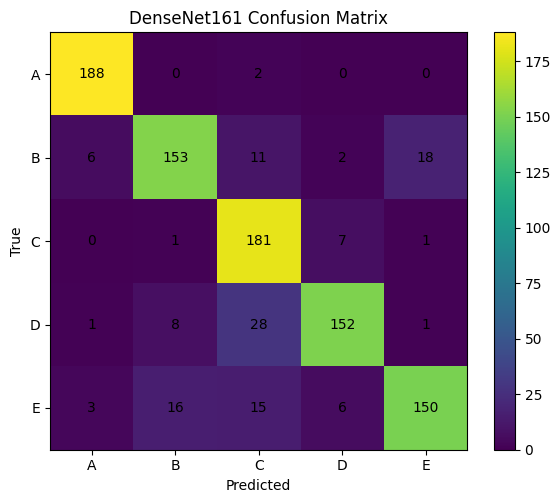

최대 오류 쌍: D → C
오류 횟수: 28


In [21]:
# ============================================================
# 3주차 3. DenseNet161 혼동행렬 + 최대 오류 쌍
# ============================================================

import matplotlib.pyplot as plt

trues, preds = pred_cache["DenseNet161"]

acc = accuracy_score(trues, preds)
macro_f1 = f1_score(trues, preds, average="macro")
cm = confusion_matrix(trues, preds)

print(f"Test Accuracy : {acc*100:.2f}%")
print(f"Macro F1      : {macro_f1*100:.2f}%")
print("\nClassification Report")
print(classification_report(
    trues, preds,
    target_names=["A","B","C","D","E"],
    digits=4
))
print("Confusion Matrix")
print(cm)

labels_name = ["A","B","C","D","E"]

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm)
ax.set_xticks(range(5), labels_name)
ax.set_yticks(range(5), labels_name)

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i,j], ha="center", va="center")

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("DenseNet161 Confusion Matrix")
plt.colorbar(im)
plt.tight_layout()

confusion_path = os.path.join(WEEK3_DIR, "confusion.png")
plt.savefig(confusion_path, dpi=150)
plt.show()

cm_error = cm.copy()
np.fill_diagonal(cm_error, 0)
true_idx, pred_idx = np.unravel_index(cm_error.argmax(), cm_error.shape)
error_count = cm_error[true_idx, pred_idx]

print("최대 오류 쌍:", f"{labels_name[true_idx]} → {labels_name[pred_idx]}")
print("오류 횟수:", int(error_count))

with open(os.path.join(WEEK3_DIR, "dense_result.json"), "w", encoding="utf-8") as f:
    json.dump({
        "test_accuracy_percent": float(acc*100),
        "macro_f1_percent": float(macro_f1*100),
        "max_error_pair": f"{labels_name[true_idx]} -> {labels_name[pred_idx]}",
        "max_error_count": int(error_count)
    }, f, ensure_ascii=False, indent=2)

## 단계 4 — 5-fold 교차검증

교재 원칙대로 **윈도우가 아니라 시행(CSV 파일) 단위**로 5-fold를 만듭니다.  
각 fold마다 DenseNet161을 새로 초기화합니다.

- 전체 시행: 250
- 매 fold: Train 200 / Validation 50
- StratifiedKFold
- AdamW + Scheduler + 80 epoch

In [22]:
# ============================================================
# 3주차 4. DenseNet161 5-Fold Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

fold_rows = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(files, labels), start=1):
    print("\n" + "="*80)
    print(f"Fold {fold}/5")
    print("="*80)

    fold_train_files = [files[i] for i in tr_idx]
    fold_val_files = [files[i] for i in va_idx]

    print("Train 시행 수     :", len(fold_train_files))
    print("Validation 시행 수:", len(fold_val_files))

    Xf_tr, yf_tr = build(fold_train_files)
    Xf_va, yf_va = build(fold_val_files)

    train_loader_fold = make_loader(Xf_tr, yf_tr, shuffle=True)
    val_loader_fold = make_loader(Xf_va, yf_va, shuffle=False)

    set_seed(SEED + fold)

    m = create_densenet161().to(device)
    optimizer = torch.optim.AdamW(
        m.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )

    best_acc = -1.0
    best_f1 = -1.0
    best_epoch = 0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        m.train()
        loss_sum = 0.0

        for xb, yb in train_loader_fold:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            out = m(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()

        val_acc, val_f1, _, _ = predict_metrics(m, val_loader_fold)
        scheduler.step(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_f1 = val_f1
            best_epoch = epoch
            best_state = copy.deepcopy(m.state_dict())

        print(
            f"Fold {fold} | Epoch {epoch:02d}/{EPOCHS} | "
            f"Loss {loss_sum/len(train_loader_fold):.4f} | "
            f"Val Acc {val_acc*100:.2f}% | Macro F1 {val_f1*100:.2f}%"
        )

    torch.save(
        best_state,
        os.path.join(WEEK3_DIR, f"fold_{fold}_best.pth")
    )

    fold_rows.append({
        "Fold": fold,
        "Best Epoch": best_epoch,
        "Accuracy (%)": best_acc * 100,
        "Macro F1 (%)": best_f1 * 100
    })

    # 메모리 정리
    del m, optimizer, Xf_tr, yf_tr, Xf_va, yf_va
    del train_loader_fold, val_loader_fold
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

fold_df = pd.DataFrame(fold_rows)

mean_acc = fold_df["Accuracy (%)"].mean()
std_acc = fold_df["Accuracy (%)"].std(ddof=0)

mean_f1 = fold_df["Macro F1 (%)"].mean()
std_f1 = fold_df["Macro F1 (%)"].std(ddof=0)

fold_df.to_csv(
    os.path.join(WEEK3_DIR, "5fold_results.csv"),
    index=False
)

summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1"],
    "Mean (%)": [mean_acc, mean_f1],
    "Std (%)": [std_acc, std_f1]
})

summary_df.to_csv(
    os.path.join(WEEK3_DIR, "5fold_summary.csv"),
    index=False
)

print("\n" + "="*80)
print("5-Fold 결과")
print("="*80)
display(fold_df)
print(f"Accuracy : {mean_acc:.2f} ± {std_acc:.2f}%")
print(f"Macro F1 : {mean_f1:.2f} ± {std_f1:.2f}%")


Fold 1/5
Train 시행 수     : 200
Validation 시행 수: 50
Fold 1 | Epoch 01/80 | Loss 1.0232 | Val Acc 53.89% | Macro F1 45.03%
Fold 1 | Epoch 02/80 | Loss 0.7092 | Val Acc 68.95% | Macro F1 65.67%
Fold 1 | Epoch 03/80 | Loss 0.5822 | Val Acc 82.21% | Macro F1 82.28%
Fold 1 | Epoch 04/80 | Loss 0.5106 | Val Acc 76.21% | Macro F1 75.50%
Fold 1 | Epoch 05/80 | Loss 0.4248 | Val Acc 82.95% | Macro F1 82.71%
Fold 1 | Epoch 06/80 | Loss 0.3827 | Val Acc 84.42% | Macro F1 84.19%
Fold 1 | Epoch 07/80 | Loss 0.3397 | Val Acc 82.95% | Macro F1 82.72%
Fold 1 | Epoch 08/80 | Loss 0.3238 | Val Acc 75.58% | Macro F1 76.69%
Fold 1 | Epoch 09/80 | Loss 0.2991 | Val Acc 84.21% | Macro F1 84.10%
Fold 1 | Epoch 10/80 | Loss 0.2580 | Val Acc 87.16% | Macro F1 87.11%
Fold 1 | Epoch 11/80 | Loss 0.2761 | Val Acc 85.37% | Macro F1 85.13%
Fold 1 | Epoch 12/80 | Loss 0.2111 | Val Acc 87.26% | Macro F1 87.16%
Fold 1 | Epoch 13/80 | Loss 0.1861 | Val Acc 88.42% | Macro F1 88.47%
Fold 1 | Epoch 14/80 | Loss 0.1884 | Va

,Fold,Best Epoch,Accuracy (%),Macro F1 (%)
0,1,29,89.578947,89.482709
1,2,66,89.263158,89.245180
2,3,37,91.578947,91.514839
3,4,60,92.947368,92.938765
4,5,55,92.000000,91.959384


Accuracy : 91.07 ± 1.42%
Macro F1 : 91.03 ± 1.44%


## 단계 6 — 제출 파일 확인

아래 셀은 제출 결과물을 ZIP으로 묶습니다.  
실행이 끝난 뒤 `week3_results.zip`을 다운로드해서 보관하세요.

In [23]:
# ============================================================
# 3주차 5. 결과 파일 목록 + ZIP
# ============================================================

import shutil
from pathlib import Path

print("저장된 결과:")
for p in sorted(Path(WEEK3_DIR).glob("*")):
    print(" -", p)

zip_path = shutil.make_archive(
    "week3_results",
    "zip",
    WEEK3_DIR
)

print("\nZIP 저장 완료:", zip_path)
print("이 파일과 실행 완료된 ipynb를 보관하세요.")

저장된 결과:
 - outputs/week3/2D_CNN_best.pth
 - outputs/week3/2D_CNN_history.csv
 - outputs/week3/5fold_results.csv
 - outputs/week3/5fold_summary.csv
 - outputs/week3/DenseNet161_best.pth
 - outputs/week3/DenseNet161_history.csv
 - outputs/week3/ResNet18_best.pth
 - outputs/week3/ResNet18_history.csv
 - outputs/week3/confusion.png
 - outputs/week3/dense_result.json
 - outputs/week3/fold_1_best.pth
 - outputs/week3/fold_2_best.pth
 - outputs/week3/fold_3_best.pth
 - outputs/week3/fold_4_best.pth
 - outputs/week3/fold_5_best.pth
 - outputs/week3/model_comparison.csv

ZIP 저장 완료: /content/week3_results.zip
이 파일과 실행 완료된 ipynb를 보관하세요.


#메모

- DenseNet161 Test Accuracy
- DenseNet161 Macro F1
- confusion.png
- 최대 오류 쌍 / 횟수
- 2D CNN / ResNet18 / DenseNet161 비교표
- 각 모델 학습시간 / 파라미터 수 / 추론시간
- Fold 1~5 Accuracy / Macro F1
- 5-fold 평균 ± 표준편차

실행 결과를 ChatGPT에 다시 업로드하면 최종 **7개 항목 리포트**와 **한계 3가지 이상**, **README**, **PDF 제출본**을 완성할 수 있습니다.